# Vendor Risk Diligence Agent — Baseline Notebook

CSE 598 (Agentic AI) capstone proposal baseline, submitted by Prakruti Dangi. This notebook is a
notebook-form wrapper around the exact same code as `run_baseline.py` in this repository — it
doesn't reimplement anything, it just calls the same `baseline.baseline.run_baseline_case()`
function so there's a single source of truth for what "the baseline" actually does.

**The problem.** A procurement lead evaluating a new SaaS vendor has to read a security
questionnaire, a draft contract, a financial summary, and reference-call notes, usually under a
deadline. No single document tells the whole story — a vendor can sound strong on a reference call
while its own security questionnaire admits there's no documented incident response plan — and
reviewers rarely have time to cross-check every claim in every source. This baseline is the
minimal, single-LLM-call starting point for that problem; see `README.md` for the full picture,
including the more structured multi-agent system planned for later this semester and the working
prototype of it that already exists.

## Setup

```bash
pip install -r requirements.txt
cp .env.example .env
```

Open `.env` and set `GROQ_API_KEY` to a free key from https://console.groq.com/keys (no credit
card required) if you want to make a real API call below. Everything else in `.env` already has a
safe default. Set `DRY_RUN=true` (already the default below) to run this whole notebook offline
with a canned response instead — no key needed at all, useful for grading without one.

In [1]:
import sys, os, json
from pathlib import Path

# Make sure the local `baseline` package is importable regardless of where Jupyter was launched from
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "baseline").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from dotenv import load_dotenv
load_dotenv(REPO_ROOT / ".env")

os.environ.setdefault("DRY_RUN", "true")  # flip to "false" (and set GROQ_API_KEY in .env) for a real call
print("Repo root:", REPO_ROOT)
print("DRY_RUN  :", os.environ.get("DRY_RUN"))

Repo root: /tmp/vendor-risk-baseline
DRY_RUN  : true


## The test case: four input documents

`examples/case_01_northwind_analytics/` describes one fictional SaaS vendor. It's deliberately
adversarial: on the surface the vendor looks strong (revenue growing, SOC 2 Type II, a positive
reference call), but its own security questionnaire admits there is no documented incident
response plan. A careful reviewer should flag that gap as the primary concern.

In [2]:
from baseline.baseline import REQUIRED_FILES

case_dir = REPO_ROOT / "examples" / "case_01_northwind_analytics"
for name in REQUIRED_FILES:
    text = (case_dir / name).read_text()
    print(f"--- {name} ({len(text)} chars) ---")
    print(text[:350].rstrip() + ("..." if len(text) > 350 else ""))
    print()

--- financial_summary.md (506 chars) ---
# Financial Summary -- Northwind Analytics

## Quarterly revenue

| Quarter | Revenue |
|---|---|
| Q3-2025 | $485,243 |
| Q4-2025 | $508,975 |
| Q1-2026 | $533,867 |

## Customer base

Our largest customer currently represents approximately 19% of total revenue.

## Funding & runway

We're well-capitalized with a comfortable operating runway.

##...

--- security_questionnaire.md (719 chars) ---
# Security Questionnaire -- Northwind Analytics

**Q: Is customer data encrypted at rest?**
A: Yes.

**Q: Is MFA enforced for all employee access to production systems?**
A: Yes.

**Q: Do you have a documented, tested incident response plan?**
A: Not formally, no -- we handle incidents as they come up. We don't currently have a written runbook, but...

--- contract_draft.md (858 chars) ---
# Master Service Agreement (Excerpt) -- Northwind Analytics

**Section 6. Limitation of Liability.** Except for breaches of confidentiality, each party's aggregate
li

## Running the baseline

One call, no decomposition: all four documents get concatenated into a single fixed prompt
(`baseline/prompts.py`), sent once to Groq, and the JSON response is parsed and returned. This
cell runs the real code path — with `DRY_RUN=true` (the default above) it returns a canned
response with zero network calls, which is what actually executes below so this notebook can be
graded without an API key; set `DRY_RUN=false` and re-run to make a live call instead.

In [3]:
from baseline.baseline import run_baseline_case

result = run_baseline_case(case_dir)
print(json.dumps(result, indent=2))

{
  "memo": "# Vendor Risk Brief: case_01_northwind_analytics\n\n[DRY_RUN] This is a canned placeholder memo returned instead of a real model call. Set DRY_RUN=false and add a real GROQ_API_KEY in .env to see the model's actual output.",
  "identified_issues": [],
  "recommendation": "approve",
  "case_id": "case_01_northwind_analytics"
}


## What a real run against Groq actually produced

The cell above ran in `DRY_RUN` mode so this notebook works without an API key. The output below
is not hypothetical, though — it's the actual JSON this same baseline produced on a real run
against Groq, loaded here from `examples/expected_output/`, alongside a screenshot of that same
terminal run for a second form of proof it actually executed successfully.

## Executive Summary
Northwind Analytics demonstrates solid financial health with quarterly revenue increasing from $485,243 in Q3-2025 to $533,867 in Q1-2026, a diversified customer base (largest client <20% of revenue), and a comfortable operating runway. Security controls such as encryption at rest, MFA, and a 24-hour breach notification commitment are in place, and a SOC 2 Type II report is available. The contract provides standard liability caps (3x fees) and a clear data-deletion timeline on termination. A recent reference call praises the vendor's security-conscious team.

## Top Concerns
- **No formal, documented incident response plan** - the vendor handles incidents ad-hoc, which increases risk of inconsistent handling and delayed remediation.
- **Liability cap limited to 3x fees** - while typical, it may be insufficient for high-impact data breaches.

## Recommendation
Approve with conditions: require the vendor to deliver a written, tested incident response plan (including 

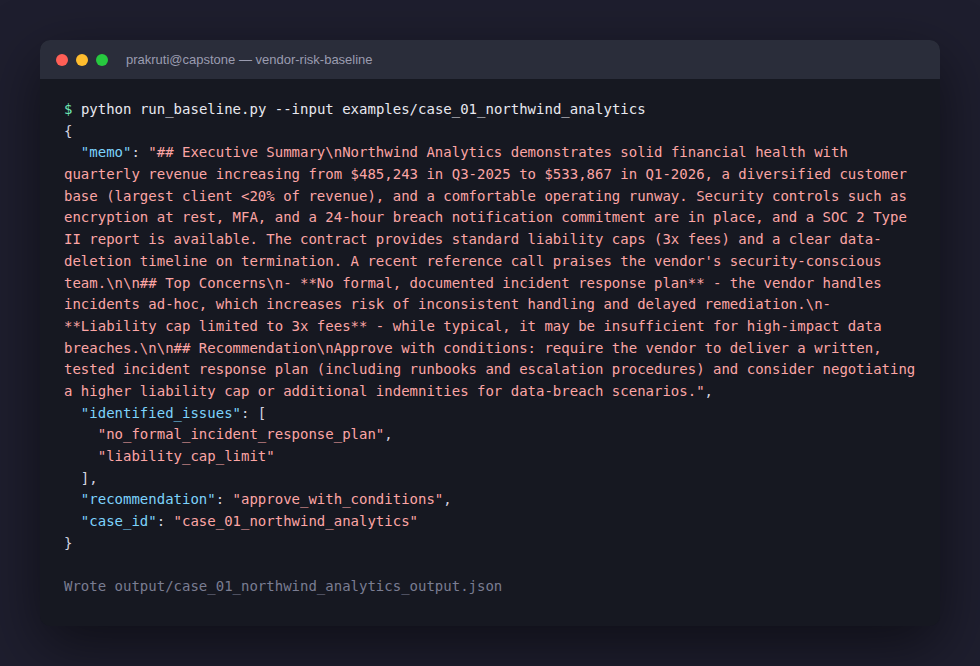

In [4]:
from IPython.display import Image, display

real_output_path = REPO_ROOT / "examples" / "expected_output" / "case_01_northwind_analytics_baseline_output.json"
real_output = json.loads(real_output_path.read_text())

print(real_output["memo"])
print()
print("identified_issues:", real_output["identified_issues"])
print("recommendation   :", real_output["recommendation"])

display(Image(filename=str(REPO_ROOT / "examples" / "expected_output" / "case_01_northwind_analytics_baseline_output_screenshot.png")))

On that real run, the baseline caught the intended issue (`no_formal_incident_response_plan`) and
recommended `approve_with_conditions` — but it also flagged the contract's standard 3x-fees
liability cap (`liability_cap_limit`) as a concern, even though that term is typical and not
actually problematic. That's a well-written but not load-bearing false alarm, and exactly the kind
of noise the planned cross-source verifier and deterministic policy-diff tool (see `README.md`,
"What this baseline is, and isn't") are meant to reduce.

## Known limitations of this baseline

- **No cross-document check.** It reads all four documents in one pass; it never extracts
  structured facts from one document and checks them against another.
- **No check against a defined standard.** It relies entirely on the model's own sense of what's
  "normal" for a contract term, which is why it raised the standard liability cap above.
- **No citation enforcement.** Nothing verifies that a claim in the memo traces back to real text
  in one of the four source documents.
- **Fixed four-document shape.** Exactly one financial summary, one security questionnaire, one
  contract, and one reference-call writeup, in the four fixed filenames above.

## Relationship to the full proposal

The written proposal (problem definition, motivation and scope, evaluation plan, and limitations
and next steps) is submitted separately as the CSE598 capstone proposal document. This notebook —
and `run_baseline.py`, which does exactly the same thing from the command line — is the "Runnable
Baseline" and "Test Case and Baseline Output" evidence referenced from that document. See
`README.md` in this repository for the full picture, including the already-working multi-agent
prototype this baseline is being compared against.